In [1]:
"""
Main training script for BINN, using DistributedDataParallel.

See run_binn_interactive.sh for example usage with reasonable hyperparameters.
"""
import csv
import functools
import math
import sys
import time
import random
import warnings
import subprocess
import argparse
from collections import OrderedDict
import misc_utils
from sklearn.model_selection import KFold
from mlp import ConstantParameters
from pe_gcn_model import GridCellSpatialRelationEncoder
from torch.optim.swa_utils import AveragedModel, SWALR
# from spatial_utils import *
from losses import binns_loss, compute_param_matching_loss, compute_param_violation_loss, compute_unconstrained_param_loss
import visualization_utils

# sys.path.append('C:/Users/hx293/Research_Data/BINN/')
# sys.path.append('/glade/u/home/haodixu/BINN')
# sys.path.append(r'/User/homes/ftao/Projects/BINNS/src_binns')

# Set HDF5_DISABLE_VERSION_CHECK to suppress version mismatch error
import os
os.environ['HDF5_DISABLE_VERSION_CHECK'] = '2'

from datetime import datetime, timedelta
import pandas as pd
from pandas import DataFrame as df
import numpy as np
from scipy.interpolate import pchip_interpolate

print("Start binns_DDP")



# Temporary hack to avoid printing np.float64(...) when printing out numpy scalars.
# TODO fix this
np.set_printoptions(legacy="1.21")

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
import multiprocessing
# from torch.multiprocessing import Process  # TODO CHECK
from multiprocessing import Process
from scipy.io import loadmat
import netCDF4 as ncread 
import mat73
from matplotlib import pyplot as plt

# LibMTL is a library for advanced multi-task loss weighting methods.
# Commenting these out as they are not essential for BINN training.
# import LibMTL.weighting as weighting_method
# import LibMTL.architecture as architecture_method

# @joshuafan: previously we set default dtype to float64 to avoid underflow in process-based model.
# Now checking float32 with fixed process-based model.
torch.set_default_dtype(torch.float32)

###################################
# Import CLM5 process-based model #
###################################
# fun_model_simu predicts at user-specified depths. fun_model_prediction predicts at 20 default layers.
from fun_matrix_COMPAS_Hardy import fun_model_simu, fun_model_prediction
from fun_matrix_COMPAS_Hardy_bulk_converge import fun_bulk_simu

# KAN Model
import pykan_josh

device = 'cpu'

Start binns_DDP


In [4]:
## Input data
job_id = '20250601-165700_KAN_ONELAYER_GRIDMARGIN_COMPAS2_9700234_lr=1e-02_fold=0_seed=111'

data_dir_input = 'D:/Nutstore/Research_Data/BINN/ENSEMBLE/INPUT_DATA/'
model_dir_input = 'D:/BINN/OUTPUT_DATA/neural_network/'

data_dir_output = model_dir_input + job_id + '/KAN_Propotional_Change/'
if not os.path.exists(data_dir_output):
	os.makedirs(data_dir_output)

# constants
cesm2_case_name = 'sasu_f05_g16_checked_step4'
start_year = 661
end_year = 680

time_domain = 'whole_time' # 'whole_time', 'before_1985', 'after_1985', 'random_half_1', 'random_half_2'
model_name = 'cesm2_clm5_cen_vr_v2'

start_id = 1
end_id = 5000
is_resubmit = 0

# constants
month_num = 12 
soil_cpool_num = 7
soil_decom_num = 20


## Dummy args input
dummy_args = argparse.Namespace()
dummy_args.seed = 111
dummy_args.model = 'kan'
dummy_args.dropout_prob = 0
dummy_args.param_constraint = 'hardsigmoid'
dummy_args.losses = ["smooth_l1", "param_reg", "param_violation", "kan_l1", "kan_entropy", "kan_coefdiff"]
# KAN
dummy_args.kan_grid = 30
dummy_args.kan_grid_margin = 2.0
dummy_args.kan_update_grid = 0
dummy_args.kan_noise = 0.3
dummy_args.kan_base_fun = "identity"
dummy_args.kan_affine_trainable = True
dummy_args.categorical = 'embedding'
dummy_args.kan_absolute_deviation = True

# default
dummy_args.vertical_mixing = 'original'
dummy_args.vectorized = 'yes'
dummy_args.pos_enc = 'none'
dummy_args.use_bn = False
dummy_args.activation = 'leaky_relu'
dummy_args.min_temp = 1
dummy_args.max_temp = 1
dummy_args.init = "xavier_uniform"
dummy_args.width = 128
dummy_args.num_layers = 1
dummy_args.residual = False
dummy_args.feature_dropout = 0
dummy_args.standardize_input = False
dummy_args.standardize_output = False
dummy_args.features = 'ten'



para_names = ['diffus', 'cryo', 'q10', 'efolding', 'taucwd', 'taul1', 'taul2', 'tau4doc', 'tau4mic', 'tau4poc', 'tau4maom','fl1_MIC', 'fl2_MIC', 'fMIC_DOC', 'fMIC_POC', 'fDOC_MAOM', 'CUEl1', 'CUEl2', 'CUEDOC', 'w-scaling', 'beta']
para_index = np.arange(len(para_names))
print("Predicted parameter number: ", len(para_names))


def set_seeds(seed):
	"""
	Attempts to set all random seeds to improve reproducibility.
	"""
	random.seed(seed)
	np.random.seed(seed)
	torch.manual_seed(seed)
	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
	torch.backends.cudnn.deterministic = True
	torch.backends.cudnn.benchmark = True

# Set seeds for reproducibility
set_seeds(dummy_args.seed)


Predicted parameter number:  21


In [5]:
#-------------------------------
# wosis data
#-------------------------------
# load wosis data

# The site information for each SOC profile. 
# Names for each column are "profile_id" "country_id" "country_name" "lon" "lat" "layer_num" “date”. 
nc_data_middle = ncread.Dataset(data_dir_input + 'wosis_2019_snap_shot/soc_profile_wosis_2019_snapshot_hugelius_mishra.nc') # wosis profile info
wosis_profile_info = nc_data_middle['soc_profile_info'][:].data.transpose()
nc_data_middle.close()

# The full dataset which contains SOC content information at each layer
# layer_info: "profile_id, date, upper_depth, lower_depth, node_depth, soc_layer_weight, soc_stock, bulk_denstiy, is_pedo"
nc_data_middle = ncread.Dataset(data_dir_input + 'wosis_2019_snap_shot/soc_data_integrate_wosis_2019_snapshot_hugelius_mishra.nc') # wosis SOC info
wosis_soc_info = nc_data_middle['data_soc_integrate'][:].data.transpose()
nc_data_middle.close()

#-------------------------------
# POM and MAOM data
#-------------------------------
# Load POM and MAOM data from excel file
data_POM_MAOM = pd.read_excel(data_dir_input + 'POM_MAOM/new-data-no wetland and bareland-80-120.xlsx')
# Drop the unit row 
data_POM_MAOM = data_POM_MAOM.drop(0)
# Store the shape of the data
POM_MAOM_profile_num = data_POM_MAOM.shape
print("Shape of data_POM_MAOM: ", POM_MAOM_profile_num)

# soil depths info
# width between two interfaces
dz = np.array([2.000000000000000E-002, 4.000000000000000E-002, 6.000000000000000E-002, \
8.000000000000000E-002, 0.120000000000000, 0.160000000000000, \
0.200000000000000, 0.240000000000000, 0.280000000000000, \
0.320000000000000, 0.360000000000000, 0.400000000000000, \
0.440000000000000, 0.540000000000000, 0.640000000000000, \
0.740000000000000, 0.840000000000000, 0.940000000000000, \
1.04000000000000, 1.14000000000000, 2.39000000000000, \
4.67553390593274, 7.63519052838329, 11.1400000000000, \
15.1154248593737])

# depth of the interface
zisoi = np.array([2.000000000000000E-002, 6.000000000000000E-002, \
0.120000000000000, 0.200000000000000, 0.320000000000000, \
0.480000000000000, 0.680000000000000, 0.920000000000000, \
1.20000000000000, 1.52000000000000, 1.88000000000000, \
2.28000000000000, 2.72000000000000, 3.26000000000000, \
3.90000000000000, 4.64000000000000, 5.48000000000000, \
6.42000000000000, 7.46000000000000, 8.60000000000000, \
10.9900000000000, 15.6655339059327, 23.3007244343160, \
34.4407244343160, 49.5561492936897])

zisoi_0 = 0

# depth of the node
zsoi = np.array([1.000000000000000E-002, 4.000000000000000E-002, 9.000000000000000E-002, \
0.160000000000000, 0.260000000000000, 0.400000000000000, \
0.580000000000000, 0.800000000000000, 1.06000000000000, \
1.36000000000000, 1.70000000000000, 2.08000000000000, \
2.50000000000000, 2.99000000000000, 3.58000000000000, \
4.27000000000000, 5.06000000000000, 5.95000000000000, \
6.94000000000000, 8.03000000000000, 9.79500000000000, \
13.3277669529664, 19.4831291701244, 28.8707244343160, \
41.9984368640029])

# depth between two node
dz_node = zsoi - np.append(np.array([0]), zsoi[:-1], axis = 0)

# cesm2 resolution
cesm2_resolution_lat = 180/384
cesm2_resolution_lon = 360/576
lon_grid = np.arange((-180 + cesm2_resolution_lon/2), 180, cesm2_resolution_lon)
lat_grid = np.arange((90 - cesm2_resolution_lat/2), -90, -cesm2_resolution_lat)

# load cesm2 input
var_name_list = ['nbedrock', 'ALTMAX', 'ALTMAX_LASTYEAR', 'CELLSAND', 'NPP', \
	'SOILPSI', 'TSOI', \
	'W_SCALAR', 'T_SCALAR', 'O_SCALAR', 'FPI_vr', \
	'LITR1_INPUT_ACC_VECTOR', 'LITR2_INPUT_ACC_VECTOR', 'LITR3_INPUT_ACC_VECTOR', 'CWD_INPUT_ACC_VECTOR', \
	'TOTSOMC']

var_name_list_rename =  ['cesm2_simu_nbedrock', 'cesm2_simu_altmax', 'cesm2_simu_altmax_last_year', 'cesm2_simu_cellsand', 'cesm2_simu_npp', \
	'cesm2_simu_soil_water_potnetial', 'cesm2_simu_soil_temperature', \
	'cesm2_simu_w_scalar', 'cesm2_simu_t_scalar', 'cesm2_simu_o_scalar', 'cesm2_simu_n_scalar', \
	'cesm2_simu_input_vector_litter1', 'cesm2_simu_input_vector_litter2', 'cesm2_simu_input_vector_litter3', 'cesm2_simu_input_vector_cwd', \
	'cesm2_simu_soc_stock']

for ivar in np.arange(0, len(var_name_list)):
	# load simulation from CESM2
	var_record_monthly_mean = mat73.loadmat(data_dir_input + 'cesm2_simu/spinup_ss/' + cesm2_case_name + '_cesm2_ss_4da_' + str(start_year) + '_' + str(end_year) + '_' + var_name_list[ivar] + '.mat')
	var_record_monthly_mean = var_record_monthly_mean['var_record_monthly_mean']
	exec(var_name_list_rename[ivar] + ' = var_record_monthly_mean')
# end

for ilayer in np.arange(0, soil_decom_num):
	cesm2_simu_input_vector_litter1[:, :, ilayer, :] = cesm2_simu_input_vector_litter1[:, :, ilayer, :]*dz[ilayer]
	cesm2_simu_input_vector_litter2[:, :, ilayer, :] = cesm2_simu_input_vector_litter2[:, :, ilayer, :]*dz[ilayer]
	cesm2_simu_input_vector_litter3[:, :, ilayer, :] = cesm2_simu_input_vector_litter3[:, :, ilayer, :]*dz[ilayer]
	cesm2_simu_input_vector_cwd[:, :, ilayer, :] = cesm2_simu_input_vector_cwd[:, :, ilayer, :]*dz[ilayer]
#end

cesm2_simu_input_sum_litter1 = np.sum(cesm2_simu_input_vector_litter1, axis = 2)
cesm2_simu_input_sum_litter2 = np.sum(cesm2_simu_input_vector_litter2, axis = 2)
cesm2_simu_input_sum_litter3 = np.sum(cesm2_simu_input_vector_litter3, axis = 2)
cesm2_simu_input_sum_cwd = np.sum(cesm2_simu_input_vector_cwd, axis = 2)

del cesm2_simu_input_vector_litter1, cesm2_simu_input_vector_litter2, cesm2_simu_input_vector_litter3, cesm2_simu_input_vector_cwd


############################################
# Select subset of observations (profiles) #
############################################
# Representative points
sample_profile_id = loadmat(data_dir_input + 'POM_MAOM/eligible_profile_loc_1_cesm2_clm5_cen_vr_v2_whole_time.mat')

# NOTE: Not sure why "sample_profile_id" shape is [100, 50] before flattening?
sample_profile_id = sample_profile_id['eligible_loc_1']

# Representative points
# sample_profile_id = loadmat(data_dir_input + 'wosis_2019_snap_shot/wosis_2019_snapshot_hugelius_mishra_representative_profiles.mat')

# # NOTE: Not sure why "sample_profile_id" shape is [100, 50] before flattening?
# sample_profile_id = sample_profile_id['sample_profile_id'].flatten()

# convert the number to be starting from 0 in python world
sample_profile_id = sample_profile_id - 1

profile_collection = sample_profile_id

# # Choose the profile id with lat and lon within the range of the United States
# profile_collection = np.where(
#     (wosis_profile_info[:, 2] == 156) & 
# 	(wosis_profile_info[:, 3] >= -124.763068) & 
#     (wosis_profile_info[:, 3] <= -66.949895) & 
#     (wosis_profile_info[:, 4] >= 24.5) & 
#     (wosis_profile_info[:, 4] <= 49.384358)
# )[0]

# Reshape the profile collection to be a column vector
profile_collection = profile_collection.flatten()
# profile_collection = np.reshape(profile_collection, [profile_collection.shape[0], 1])

profile_collection = np.random.choice(profile_collection, 30000, replace=False)

profile_collection = np.reshape(profile_collection, [profile_collection.shape[0], 1])

print("Shape of profile_collection for SOC: ", profile_collection.shape)

# Assign profile id to POM and MAOM data, starting from the end of the WOSIS data
data_POM_MAOM['profile_id'] = wosis_profile_info.shape[0] + np.arange(0, POM_MAOM_profile_num[0])
# Get the length of the combined dataset
combined_profile_num = wosis_profile_info.shape[0] + POM_MAOM_profile_num[0]
print("Shape of combined dataset: ", combined_profile_num)

# Add the POM and MAOM data to the profile collection
# profile_collection = np.append(profile_collection, data_POM_MAOM['profile_id'].values)
# profile_collection = np.append(profile_collection, np.random.choice(data_POM_MAOM['profile_id'].values, 1000, replace=False))

# # Select profiles within the US
# profile_collection_POM_MAOM = np.where(
# 		(data_POM_MAOM['Longitude'] >= -125) & 
# 		(data_POM_MAOM['Longitude'] <= -66) &
# 		(data_POM_MAOM['Latitude'] >= 24.5) &
# 		(data_POM_MAOM['Latitude'] <= 49.5)
# )[0]

# if len(profile_collection_POM_MAOM) > 1000:
# 	profile_collection_POM_MAOM = np.random.choice(profile_collection_POM_MAOM, 1000, replace=False)

# # Select profiles within the US
# profile_collection_POM_MAOM = np.where(
# 		(data_POM_MAOM['Longitude'] >= -125) & 
# 		(data_POM_MAOM['Longitude'] <= -66) &
# 		(data_POM_MAOM['Latitude'] >= 24.5) &
# 		(data_POM_MAOM['Latitude'] <= 49.5)
# )[0]

# profile_collection = np.append(profile_collection, data_POM_MAOM['profile_id'].values[profile_collection_POM_MAOM])

# Add the POM and MAOM data to the profile collection
profile_collection = np.append(profile_collection, data_POM_MAOM['profile_id'].values)

profile_collection = np.reshape(profile_collection, [profile_collection.shape[0], 1])

profile_range = np.arange(0, len(profile_collection))

print('number of profiles: ', len(profile_collection))

print(datetime.now(), '------------all input data loaded------------')

#---------------------------------------------------
# wrap up soc data for NN
#---------------------------------------------------
obs_soc_matrix = np.ones([len(profile_collection), 200])*np.nan  # Each row is a profile. Each non-nan column is an SOC observation
# POM and MAOM data
obs_POM_matrix = np.ones([len(profile_collection), 200])*np.nan
obs_MAOM_matrix = np.ones([len(profile_collection), 200])*np.nan
obs_depth_matrix = np.ones([len(profile_collection), 200])*np.nan  # Each row is a profile. Each column represents the depth of the corresponding SOC observation in "obs_soc_matrix"
obs_upper_depth_matrix = np.ones([len(profile_collection), 200])*np.nan  # Each row is a profile. Each column represents the upper depth of the corresponding SOC observation in "obs_soc_matrix"
obs_lower_depth_matrix = np.ones([len(profile_collection), 200])*np.nan  # Each row is a profile. Each column represents the lower depth of the corresponding SOC observation in "obs_soc_matrix"
obs_lon_lat_loc = np.ones([len(profile_collection), 2])*np.nan  # Each row is a profile. First column is longitude, second column is latitude

model_force_input_vector_cwd = np.ones([len(profile_collection), month_num])*np.nan
model_force_input_vector_litter1 = np.ones([len(profile_collection), month_num])*np.nan
model_force_input_vector_litter2 = np.ones([len(profile_collection), month_num])*np.nan
model_force_input_vector_litter3 = np.ones([len(profile_collection), month_num])*np.nan

model_force_altmax_lastyear_profile = np.ones([len(profile_collection), month_num])*np.nan
model_force_altmax_current_profile = np.ones([len(profile_collection), month_num])*np.nan
model_force_nbedrock = np.ones([len(profile_collection), month_num])*np.nan

model_force_xio = np.ones([len(profile_collection), soil_decom_num, month_num])*np.nan
model_force_xin = np.ones([len(profile_collection), soil_decom_num, month_num])*np.nan

model_force_sand_vector = np.ones([len(profile_collection), soil_decom_num, month_num])*np.nan

model_force_soil_temp_profile = np.ones([len(profile_collection), soil_decom_num, month_num])*np.nan
model_force_soil_water_profile = np.ones([len(profile_collection), soil_decom_num, month_num])*np.nan

# record the sum of recorded layers for all profiles
layer_num_record = 0

for iprofile_hat in profile_range:
	# profile num
	iprofile = profile_collection[iprofile_hat]
	# profile id
	if iprofile < wosis_profile_info.shape[0]:
		profile_id = wosis_profile_info[iprofile, 0]
		# find currently using profile
		loc_profile = np.where(wosis_soc_info[:, 0] == profile_id)[0]
		# find the lon and lat info of soil profile
		lon_profile = wosis_profile_info[iprofile, 3]
		lat_profile = wosis_profile_info[iprofile, 4]
		
		lat_loc = np.where(abs(lat_profile - lat_grid) == min(abs(lat_profile - lat_grid)))[0][0]
		lon_loc = np.where(abs(lon_profile - lon_grid) == min(abs(lon_profile - lon_grid)))[0][0]
		
		# info of the node depth of profile  
		wosis_layer_depth = wosis_soc_info[loc_profile, 4]
		# observed C info (gC/m3)
		wosis_layer_obs = wosis_soc_info[loc_profile, 6]
		# check how many layers are recorded
		layer_num_record = layer_num_record + len(wosis_layer_obs)
		# observced upper depth of each layer
		wosis_layer_upper_depth = wosis_soc_info[loc_profile, 2]
		# observced lower depth of each layer
		wosis_layer_lower_depth = wosis_soc_info[loc_profile, 3]
		# exclude nan values
		valid_soc_loc = np.where((np.isnan(wosis_layer_obs) == False) & (np.isnan(wosis_layer_depth) == False) & (np.isnan(wosis_layer_upper_depth) == False) & (np.isnan(wosis_layer_lower_depth) == False))
		# valid layer number
		num_layers = len(valid_soc_loc[0])

		if num_layers > 0:
			wosis_layer_depth = wosis_layer_depth[valid_soc_loc]/100 # convert unit from cm to m
			wosis_layer_obs = wosis_layer_obs[valid_soc_loc]
			wosis_layer_upper_depth = wosis_layer_upper_depth[valid_soc_loc]/100
			wosis_layer_lower_depth = wosis_layer_lower_depth[valid_soc_loc]/100
			
			obs_depth_matrix[iprofile_hat, 0:num_layers] = wosis_layer_depth
			obs_soc_matrix[iprofile_hat, 0:num_layers] = wosis_layer_obs
			obs_upper_depth_matrix[iprofile_hat, 0:num_layers] = wosis_layer_upper_depth
			obs_lower_depth_matrix[iprofile_hat, 0:num_layers] = wosis_layer_lower_depth
		# end if num_layers > 0:
	else:
		profile_id = iprofile[0]
		# print('profile_id: ', profile_id)
		layer_num_record += 1
		# find the lon and lat info of soil profile
		lon_profile = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'Longitude'].values[0]
		lat_profile = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'Latitude'].values[0]

		lat_loc = np.where(abs(lat_profile - lat_grid) == min(abs(lat_profile - lat_grid)))[0][0]
		lon_loc = np.where(abs(lon_profile - lon_grid) == min(abs(lon_profile - lon_grid)))[0][0]

		# info of the node depth of profile
		obs_depth_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'Node_Depth'].values / 100 # convert unit from cm to m
		# obs_soc_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'SOC_stock_gC_m3'].values # Unit: gC/m3
		obs_POM_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'POC_stock_gC_m3'].values
		obs_MAOM_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'MAOC_stock_gC_m3'].values
		obs_upper_depth_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'DEPTH-top'].values / 100 # convert unit from cm to m
		obs_lower_depth_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'DEPTH-bottom'].values / 100 # convert unit from cm to m

	obs_lon_lat_loc[iprofile_hat, :] = [lon_loc, lat_loc]

	# input vector
	model_force_input_vector_cwd[iprofile_hat, :] = cesm2_simu_input_sum_cwd[lat_loc, lon_loc, :]
	model_force_input_vector_litter1[iprofile_hat, :] = cesm2_simu_input_sum_litter1[lat_loc, lon_loc, :]
	model_force_input_vector_litter2[iprofile_hat, :] = cesm2_simu_input_sum_litter2[lat_loc, lon_loc, :]
	model_force_input_vector_litter3[iprofile_hat, :] = cesm2_simu_input_sum_litter3[lat_loc, lon_loc, :]
	# altmax current and last year
	model_force_altmax_lastyear_profile[iprofile_hat, :] = cesm2_simu_altmax_last_year[lat_loc, lon_loc, :]
	model_force_altmax_current_profile[iprofile_hat, :] = cesm2_simu_altmax[lat_loc, lon_loc, :]
	# nbedrock
	model_force_nbedrock[iprofile_hat, :] = cesm2_simu_nbedrock[lat_loc, lon_loc, :]
	# oxygen scalar
	model_force_xio[iprofile_hat, :, :] = cesm2_simu_o_scalar[lat_loc, lon_loc, 0:soil_decom_num, :]
	# nitrogen scalar
	model_force_xin[iprofile_hat, :, :] = cesm2_simu_n_scalar[lat_loc, lon_loc, 0:soil_decom_num, :]
	# sand content
	model_force_sand_vector[iprofile_hat, :, :] = cesm2_simu_cellsand[lat_loc, lon_loc, 0:soil_decom_num, :]
	# soil temperature and water potential
	model_force_soil_temp_profile[iprofile_hat, :, :] = cesm2_simu_soil_temperature[lat_loc, lon_loc, 0:soil_decom_num, :]
	model_force_soil_water_profile[iprofile_hat, :, :] = cesm2_simu_w_scalar[lat_loc, lon_loc, 0:soil_decom_num, :]
# end

# check the overall number of layers in the profile
print("Number of layers in profile: " + str(layer_num_record))
print(datetime.now(), '------------soc data prepared------------')

Shape of data_POM_MAOM:  (3286, 16)
Shape of profile_collection for SOC:  (30000, 1)
Shape of combined dataset:  117212
number of profiles:  33286
2025-07-03 18:45:42.488058 ------------all input data loaded------------


C:\Users\hx293\AppData\Local\Temp\ipykernel_31764\1010349775.py:275: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  obs_depth_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'Node_Depth'].values / 100 # convert unit from cm to m
C:\Users\hx293\AppData\Local\Temp\ipykernel_31764\1010349775.py:277: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  obs_POM_matrix[iprofile_hat, 0] = data_POM_MAOM.loc[data_POM_MAOM['profile_id'] == profile_id, 'POC_stock_gC_m3'].values
C:\Users\hx293\AppData\Local\Temp\ipykernel_31764\1010349775.py:278: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is de

Number of layers in profile: 160222
2025-07-03 18:45:51.999824 ------------soc data prepared------------


In [6]:
#################################################
# Environmental feature list                    #
#################################################
env_info_names = ['ProfileNum', 'ProfileID', 'LayerNum', 'Lon', 'Lat', 'Date', \
'Rmean', 'Rmax', 'Rmin', \
'ESA_Land_Cover', \
'ET', \
'IGBP', 'Climate', 'Soil_Type', 'NPPmean', 'NPPmax', 'NPPmin', \
'Veg_Cover', \
'BIO1', 'BIO2', 'BIO3', 'BIO4', 'BIO5', 'BIO6', 'BIO7', 'BIO8', 'BIO9', 'BIO10', 'BIO11', 'BIO12', 'BIO13', 'BIO14', 'BIO15', 'BIO16', 'BIO17', 'BIO18', 'BIO19', \
'Abs_Depth_to_Bedrock', \
'Bulk_Density_0cm', 'Bulk_Density_30cm', 'Bulk_Density_100cm',\
'CEC_0cm', 'CEC_30cm', 'CEC_100cm', \
'Clay_Content_0cm', 'Clay_Content_30cm', 'Clay_Content_100cm', \
'Coarse_Fragments_v_0cm', 'Coarse_Fragments_v_30cm', 'Coarse_Fragments_v_100cm', \
'Depth_Bedrock_R', \
'Garde_Acid', \
'Occurrence_R_Horizon', \
'pH_Water_0cm', 'pH_Water_30cm', 'pH_Water_100cm', \
'Sand_Content_0cm', 'Sand_Content_30cm', 'Sand_Content_100cm', \
'Silt_Content_0cm', 'Silt_Content_30cm', 'Silt_Content_100cm', \
'SWC_v_Wilting_Point_0cm', 'SWC_v_Wilting_Point_30cm', 'SWC_v_Wilting_Point_100cm', \
'Texture_USDA_0cm', 'Texture_USDA_30cm', 'Texture_USDA_100cm', \
'USDA_Suborder', \
'WRB_Subgroup', \
'Drought', \
'Elevation', \
'Max_Depth', \
'Koppen_Climate_2018', \
'cesm2_npp', 'cesm2_npp_std', \
'cesm2_gpp', 'cesm2_gpp_std', \
'cesm2_vegc', \
'nbedrock', \
'R_Squared', \
'Ald_0_20',	'Ald_20_40', 'Ald_40_60', 'Ald_60_80', 'Ald_80_100', 'Alo_0_20', 'Alo_20_40', 'Alo_40_60', 'Alo_60_80', 'Alo_80_100',\
'Fed_0_20', 'Fed_20_40', 'Fed_40_60', 'Fed_60_80', 'Fed_80_100', 'Feo_0_20', 'Feo_20_40', 'Feo_40_60', 'Feo_60_80', 'Feo_80_100'
]

# Variables used in training the NN. NOTE the order changed from before.
if dummy_args.features in ["all", "all_including_lonlat"]:
	GEOGRAPHY_VARS = ['Lon', 'Lat', 'Elevation', 'Abs_Depth_to_Bedrock', 'Occurrence_R_Horizon', 'nbedrock']
	if dummy_args.features != "all_including_lonlat":
		GEOGRAPHY_VARS.remove('Lon')
		GEOGRAPHY_VARS.remove('Lat')
	CLIMATE_VARS = ['Koppen_Climate_2018', 'BIO1', 'BIO2', 'BIO3', 'BIO4', 'BIO5', 'BIO6', 'BIO7', 'BIO8', 'BIO9', 'BIO10', 'BIO11', 'BIO12', 'BIO13', 'BIO14', 'BIO15', 'BIO16', 'BIO17', 'BIO18', 'BIO19']
	SOIL_TEXTURE_VARS = ['USDA_Suborder', 'WRB_Subgroup', 'Coarse_Fragments_v_0cm', 'Coarse_Fragments_v_30cm', 'Coarse_Fragments_v_100cm',
						'Clay_Content_0cm', 'Clay_Content_30cm', 'Clay_Content_100cm', 'Silt_Content_0cm', 'Silt_Content_30cm', 'Silt_Content_100cm',
						'Texture_USDA_0cm', 'Texture_USDA_30cm', 'Texture_USDA_100cm', 'Sand_Content_0cm', 'Sand_Content_30cm', 'Sand_Content_100cm',
						'Bulk_Density_0cm', 'Bulk_Density_30cm', 'Bulk_Density_100cm']
	SOIL_CHEMICAL_VARS = ['SWC_v_Wilting_Point_0cm', 'SWC_v_Wilting_Point_30cm', 'SWC_v_Wilting_Point_100cm', 'pH_Water_0cm', 'pH_Water_30cm', 'pH_Water_100cm',
						'CEC_0cm', 'CEC_30cm', 'CEC_100cm', 'Garde_Acid']
	VEGETATION_VARS = ['ESA_Land_Cover', 'cesm2_npp', 'cesm2_npp_std', 'cesm2_vegc']
	var4nn = GEOGRAPHY_VARS + CLIMATE_VARS + SOIL_TEXTURE_VARS + SOIL_CHEMICAL_VARS + VEGETATION_VARS
elif dummy_args.features == "ten":
	# Ten handcrafted features
	var4nn = ["BIO1", "BIO12", "BIO3", "BIO15", \
		"Clay_Content_avg", "Sand_Content_avg", "Silt_Content_avg", \
		"Bulk_Density_avg",\
		"SWC_v_Wilting_Point_avg", "pH_Water_avg", "CEC_avg", \
		"Coarse_Fragments_avg", \
		# "cesm2_npp", "cesm2_vegc", \
		'Ald_avg', 'Alo_avg',\
		'Fed_avg', 'Feo_avg', \
		]

else:
	raise ValueError("Invalid features")


################################################
# Categorical variables                        #
################################################
# List of categorical variables. Inner lists group categorical
# variables that share the same categories. For example, the category IDs
# in Texture_USDA_0cm, Texture_USDA_30cm have the same semantic meaning,
# so they share an embedding space.
categorical_vars = [['ESA_Land_Cover'], ['Texture_USDA_0cm', 'Texture_USDA_30cm', 'Texture_USDA_100cm'], 
					['USDA_Suborder'], ['WRB_Subgroup'], ['Koppen_Climate_2018']]  # Variables inside a sub-list share the same categories
categorical_vars_flattened = [item for sublist in categorical_vars for item in sublist]


#############################################################################################
# Load environmental covariates, and transform to [0, 1] range based on precomputed min/max #
#############################################################################################
# Load environmental covariates
# Environment info data for WOSIS profiles
env_info = np.genfromtxt(data_dir_input + 'wosis_2019_snap_shot/env_info_SOC_with_Al_Fe.csv', delimiter = ',', skip_header = 1)
# Environment info data for POM and MAOM profiles
env_info_POM_MAOM = np.genfromtxt(data_dir_input + 'POM_MAOM/env_info_POM_MAOM_with_Al_Fe.csv', delimiter = ',', skip_header = 1)
# Merge the two datasets
env_info = np.vstack((env_info, env_info_POM_MAOM))
original_lons = env_info[:, 3].copy()  # Save the original (unscaled) lon/lat
original_lats = env_info[:, 4].copy()
env_info = df(env_info)
env_info.columns = env_info_names

# Min/max for each feature
col_max_min = loadmat(data_dir_input + 'wosis_2019_snap_shot/world_grid_envinfo_present_cesm2_clm5_cen_vr_v2_whole_time_col_max_min.mat')
col_max_min = col_max_min['col_max_min']
print("Shape of col_max_min: ", col_max_min.shape)
col_max_min_minerals = np.genfromtxt(data_dir_input + 'wosis_2019_snap_shot/Al_Fe_max_min_values.csv', delimiter = ',', skip_header = 1)
print("Shape of col_max_min_minerals: ", col_max_min_minerals.shape)
# Merge the two datasets
col_max_min = np.vstack((col_max_min, col_max_min_minerals))
print("Shape of col_max_min after merging: ", col_max_min.shape)

# Don't want to transform categorical variables, so set max/min to nan
for group in categorical_vars:
	for var in group:
		idx = env_info_names.index(var)
		col_max_min[idx, :] = np.nan

# Logic to add columns for "average" variables (e.g. average over layers).
# Also record the min/max for these new columns.
all_col_max_mins = [col_max_min]
for v in var4nn:
	if v not in env_info_names:
		var_prefix = v.split("_avg")[0]
		columns = env_info.filter(regex=rf"^{var_prefix}.*")
		env_info[v] = columns.mean(axis=1)
		indices = [env_info_names.index(col) for col in columns.columns]
		new_max_min = np.mean(col_max_min[indices, :], axis=0, keepdims=True)  # keep shape [1, 2]
		all_col_max_mins.append(new_max_min)
	else:
		idx_var = env_info_names.index(v)
		if np.isnan(col_max_min[idx_var, 0]) or np.isnan(col_max_min[idx_var, 1]):
    			# Get the min/max from the input data
			min_temp = np.nanmin(env_info[v])
			max_temp = np.nanmax(env_info[v])
			col_max_min[idx_var, 0] = min_temp
			col_max_min[idx_var, 1] = max_temp

col_max_min = np.concatenate(all_col_max_mins, axis=0)  # shape [num_columns_new, 2]

# Add average values for Ald, Alo, Fed, and Feo
env_info["0.5_Feo_avg_Alo_avg"] = (env_info["Feo_avg"] / 2 + env_info["Alo_avg"])
env_info["0.5_Fed_avg_Ald_avg"] = (env_info["Fed_avg"] / 2 + env_info["Ald_avg"])
# Update the max/min for the new columns
# Feo_avg and Alo_avg
indices_Feo = env_info.columns.get_loc("Feo_avg")
indices_Alo = env_info.columns.get_loc("Alo_avg")
indices_Fed = env_info.columns.get_loc("Fed_avg")
indices_Ald = env_info.columns.get_loc("Ald_avg")
# Get new min by adding up the min of 0.5*Feo_avg and Alo_avg
min_temp = 0.5*col_max_min[indices_Feo, 0] + col_max_min[indices_Alo, 0]
max_temp = 0.5*col_max_min[indices_Feo, 1] + col_max_min[indices_Alo, 1]
new_max_min = np.array([[min_temp, max_temp]]) 
col_max_min = np.vstack((col_max_min, new_max_min))
# env_info["0.5_Feo_avg_Alo_avg"] = (env_info["0.5_Feo_avg_Alo_avg"] - col_max_min[-1, 0])/(col_max_min[-1, 1] - col_max_min[-1, 0])
# Fed_avg and Ald_avg
min_temp = 0.5*col_max_min[indices_Fed, 0] + col_max_min[indices_Ald, 0]
max_temp = 0.5*col_max_min[indices_Fed, 1] + col_max_min[indices_Ald, 1]
new_max_min = np.array([[min_temp, max_temp]])
col_max_min = np.vstack((col_max_min, new_max_min))
# env_info["0.5_Fed_avg_Ald_avg"] = (env_info["0.5_Fed_avg_Ald_avg"] - col_max_min[-1, 0])/(col_max_min[-1, 1] - col_max_min[-1, 0])
env_info["Clay_Silt_avg"] = (env_info["Clay_Content_avg"] + env_info["Silt_Content_avg"])
indices_Clay = env_info.columns.get_loc("Clay_Content_avg")
indices_Silt = env_info.columns.get_loc("Silt_Content_avg")
# Get new min by adding up the min of Clay_Content_avg and Silt_Content_avg
min_temp = col_max_min[indices_Clay, 0] + col_max_min[indices_Silt, 0]
max_temp = col_max_min[indices_Clay, 1] + col_max_min[indices_Silt, 1]
new_max_min = np.array([[min_temp, max_temp]])
col_max_min = np.vstack((col_max_min, new_max_min))
print("max/min for Clay_Silt_avg: ", col_max_min[-1, :])


# Update var4nn to include the new columns
if dummy_args.features == "ten":
    # Ten handcrafted features
	var4nn = ["BIO1", "BIO12", "BIO3", "BIO15", \
		# "Clay_Content_avg", "Sand_Content_avg","Silt_Content_avg", \
		"Clay_Silt_avg",\
		"Bulk_Density_avg",\
		"SWC_v_Wilting_Point_avg", "pH_Water_avg", "CEC_avg", \
		"Coarse_Fragments_avg", \
		# "cesm2_npp", "cesm2_vegc", \
		# '0.5_Feo_avg_Alo_avg', \
		# '0.5_Fed_avg_Ald_avg', \
		]
	

print("Size of col_max_min: ", col_max_min.shape)
# Scale numeric features to [0, 1] based on precomputed min/max 
warnings.filterwarnings("ignore")  # Ignore warnings about subtracting nan
for ivar in np.arange(3, len(col_max_min[:, 0])):
	if np.isnan(col_max_min[ivar, :]).any():
		pass
	else:
		env_info.iloc[:, ivar] = (env_info.iloc[:, ivar] - col_max_min[ivar, 0])/(col_max_min[ivar, 1] - col_max_min[ivar, 0])
		env_info.iloc[(env_info.iloc[:, ivar] > 1), ivar] = 1
		env_info.iloc[(env_info.iloc[:, ivar] < 0), ivar] = 0
		if env_info.columns[ivar] in var4nn:
			print("Scaled variable: ", env_info.columns[ivar], " with min/max: ", col_max_min[ivar, :])
warnings.resetwarnings()

# Retain orginal lat/lon
env_info["original_lon"] = original_lons
env_info["original_lat"] = original_lats




# env_info["Ald_avg"] = (env_info["Ald_0_20"] + env_info["Ald_20_40"]) / 2
# env_info["Alo_avg"] = (env_info["Alo_0_20"] + env_info["Alo_20_40"]) / 2
# env_info["Fed_avg"] = (env_info["Fed_0_20"] + env_info["Fed_20_40"]) / 2
# env_info["Feo_avg"] = (env_info["Feo_0_20"] + env_info["Feo_20_40"]) / 2


########################################################################
# Preprocessing of categorical variables. Perhaps this should be moved
# inside the neural network itself to make usage easier.
#########################################################################
# Determine how many indices are in each categorical group
var_to_categories = dict()  # varname to number of categories
for group in categorical_vars:
	n_categories = int(np.nanmax(env_info[group]) + 1)
	for var in group:
		var_to_categories[var] = n_categories
print("Var to categories", var_to_categories)

# Compute indices of each variable after categorical variables are expanded
var_to_indices = dict()
curr_idx = 0
for var in var4nn:
	if var in var_to_categories:
		if dummy_args.categorical == "embedding":
			n_indices = dummy_args.embed_dim
		elif dummy_args.categorical == "one_hot":
			n_indices = var_to_categories[var]
		else:
			raise ValueError("Invalid dummy_args.categorical")
	else:
		n_indices = 1
	var_to_indices[var] = list(range(curr_idx, curr_idx + n_indices))
	curr_idx += n_indices

# Indices of each group after categorical variables are expanded
if dummy_args.features in ["all", "all_including_lonlat"]:
	GEOGRAPHY_INDICES = [i for var in GEOGRAPHY_VARS for i in var_to_indices[var]]
	CLIMATE_INDICES = [i for var in CLIMATE_VARS for i in var_to_indices[var]]
	SOIL_TEXTURE_INDICES = [i for var in SOIL_TEXTURE_VARS for i in var_to_indices[var]]
	SOIL_CHEMICAL_INDICES = [i for var in SOIL_CHEMICAL_VARS for i in var_to_indices[var]]
	VEGETATION_INDICES = [i for var in VEGETATION_VARS for i in var_to_indices[var]]
print("Var to indices", var_to_indices)

Shape of col_max_min:  (81, 2)
Shape of col_max_min_minerals:  (20, 2)
Shape of col_max_min after merging:  (101, 2)
max/min for Clay_Silt_avg:  [  2.         137.66666667]
Size of col_max_min:  (116, 2)
Scaled variable:  BIO1  with min/max:  [-20.26570826  32.51958342]
Scaled variable:  BIO3  with min/max:  [ 8.07464497 96.25371131]
Scaled variable:  BIO12  with min/max:  [5.000e-01 7.071e+03]
Scaled variable:  BIO15  with min/max:  [  4.95727908 178.47563124]
Scaled variable:  Bulk_Density_avg  with min/max:  [ 111.66666667 1771.        ]
Scaled variable:  SWC_v_Wilting_Point_avg  with min/max:  [ 2.         72.66666667]
Scaled variable:  pH_Water_avg  with min/max:  [40.33333333 92.66666667]
Scaled variable:  CEC_avg  with min/max:  [  0.66666667 124.        ]
Scaled variable:  Coarse_Fragments_avg  with min/max:  [ 0.         72.33333333]
Scaled variable:  Clay_Silt_avg  with min/max:  [  2.         137.66666667]
Var to categories {'ESA_Land_Cover': 23, 'Texture_USDA_0cm': 13, 'Tex

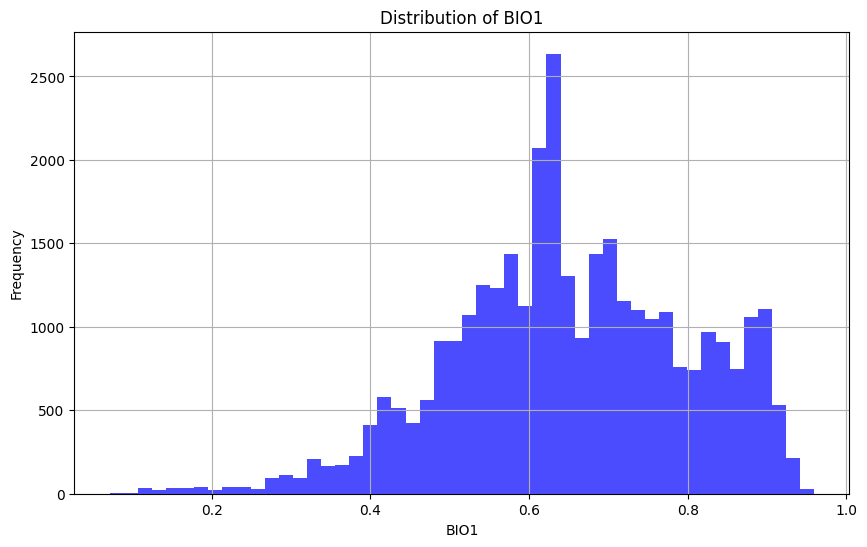

Mean of BIO1: 0.6515022834638241, Standard Deviation: 0.15026325762810713
Min of BIO1: 0.07126117029703237, Max of BIO1: 0.9592926400601322


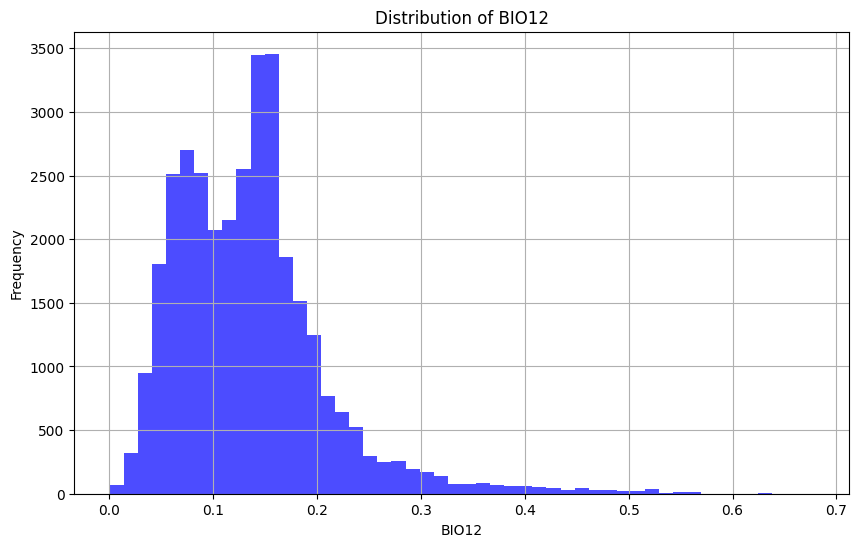

Mean of BIO12: 0.13526350878195986, Standard Deviation: 0.07323384231916527
Min of BIO12: 0.0006364472102397262, Max of BIO12: 0.6785234424722414


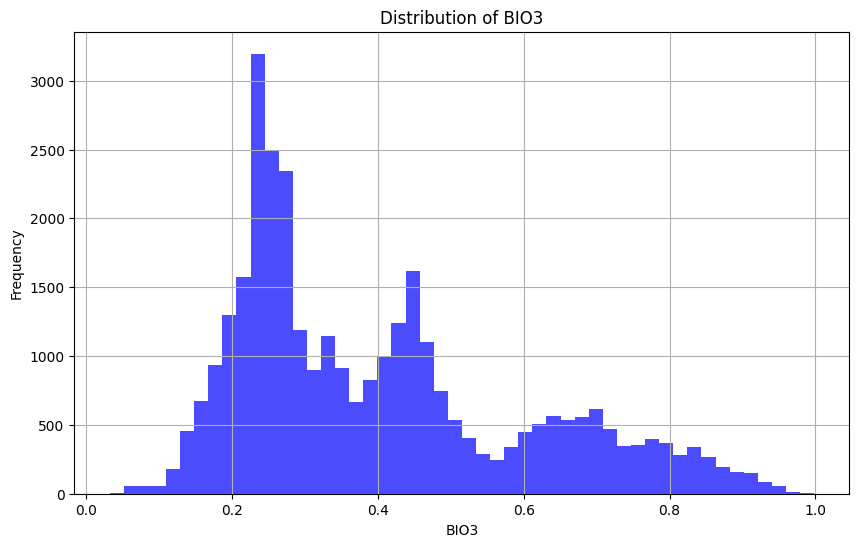

Mean of BIO3: 0.40140836143318587, Standard Deviation: 0.19813258003111878
Min of BIO3: 0.03239463409634288, Max of BIO3: 0.99833124275371


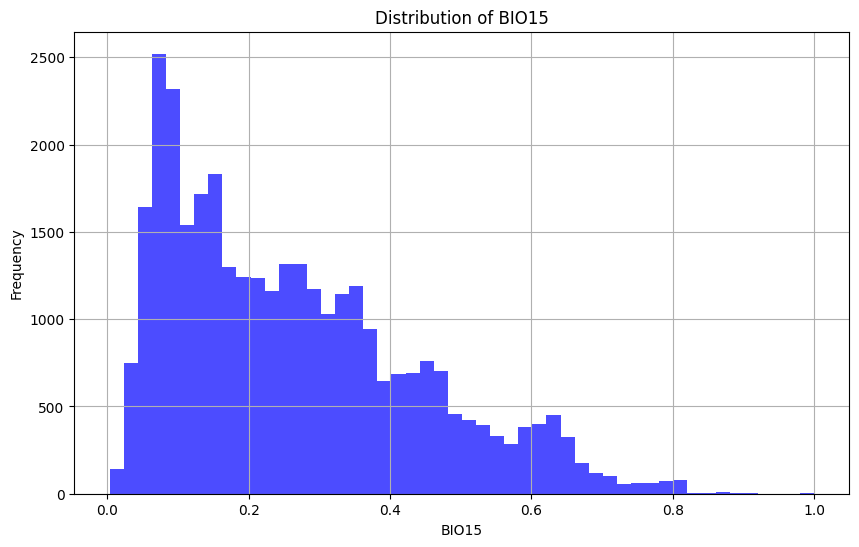

Mean of BIO15: 0.26243406494586263, Standard Deviation: 0.17533240572770623
Min of BIO15: 0.003047466511289029, Max of BIO15: 1.0


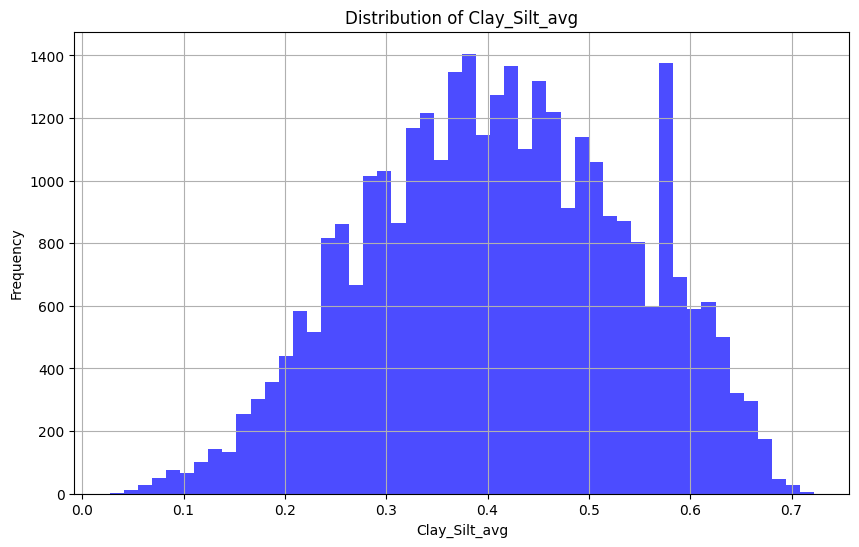

Mean of Clay_Silt_avg: 0.4107943849176192, Standard Deviation: 0.12926182340118647
Min of Clay_Silt_avg: 0.027027027027027025, Max of Clay_Silt_avg: 0.7223587223587222


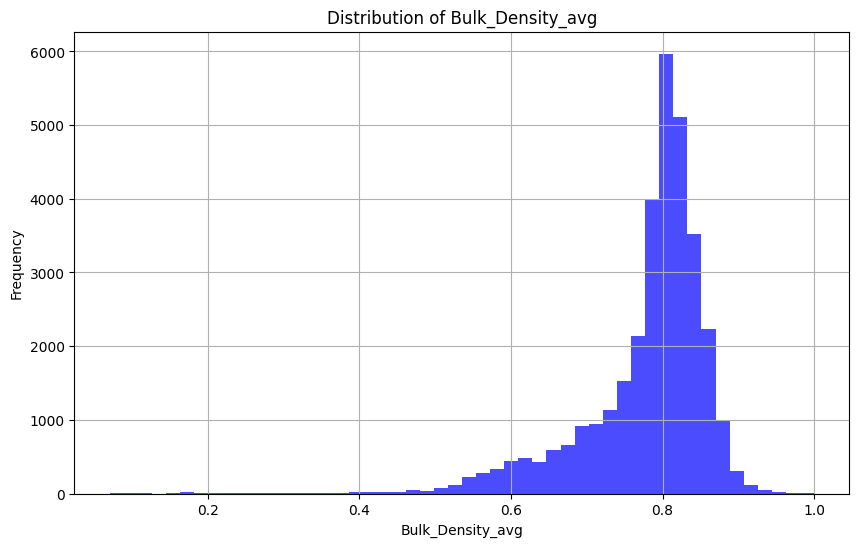

Mean of Bulk_Density_avg: 0.7790391559300726, Standard Deviation: 0.08474316317143535
Min of Bulk_Density_avg: 0.0705102450783447, Max of Bulk_Density_avg: 1.0


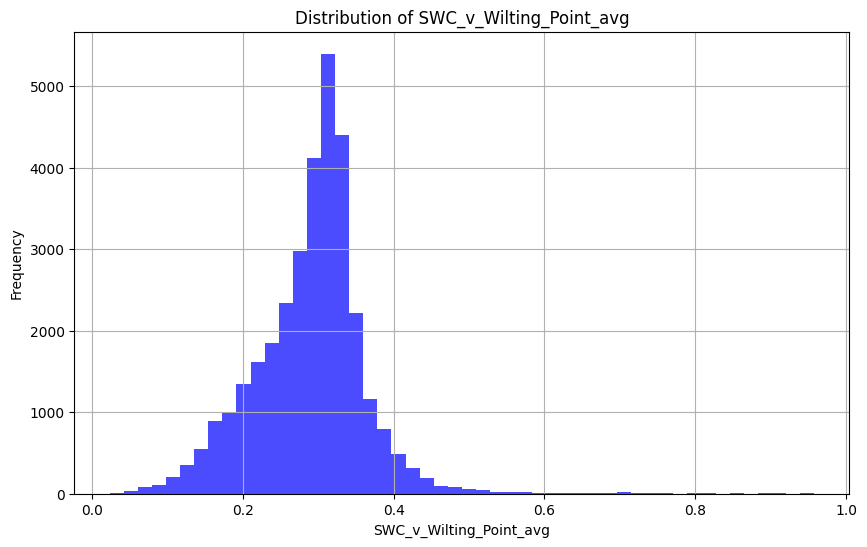

Mean of SWC_v_Wilting_Point_avg: 0.28994341575604954, Standard Deviation: 0.07405281177164036
Min of SWC_v_Wilting_Point_avg: 0.023584905660377353, Max of SWC_v_Wilting_Point_avg: 0.9575471698113207


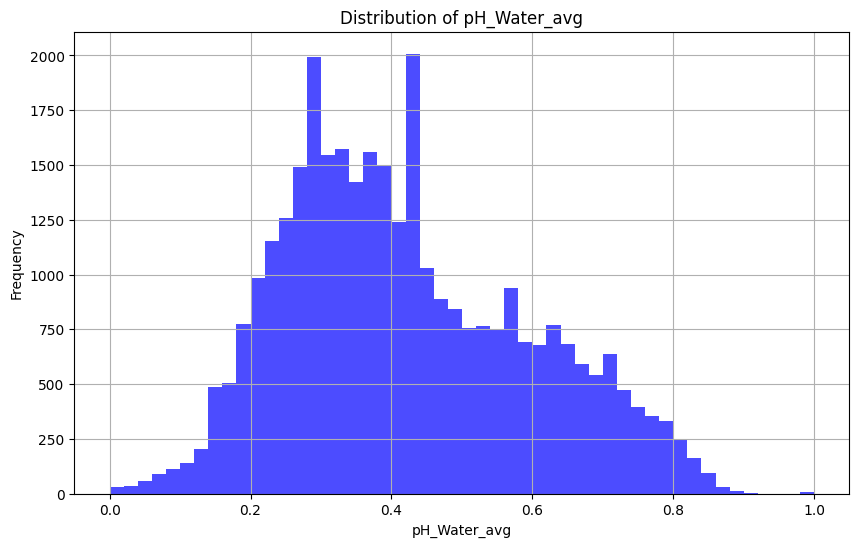

Mean of pH_Water_avg: 0.4203842985719205, Standard Deviation: 0.17337768006719795
Min of pH_Water_avg: 0.0, Max of pH_Water_avg: 1.0


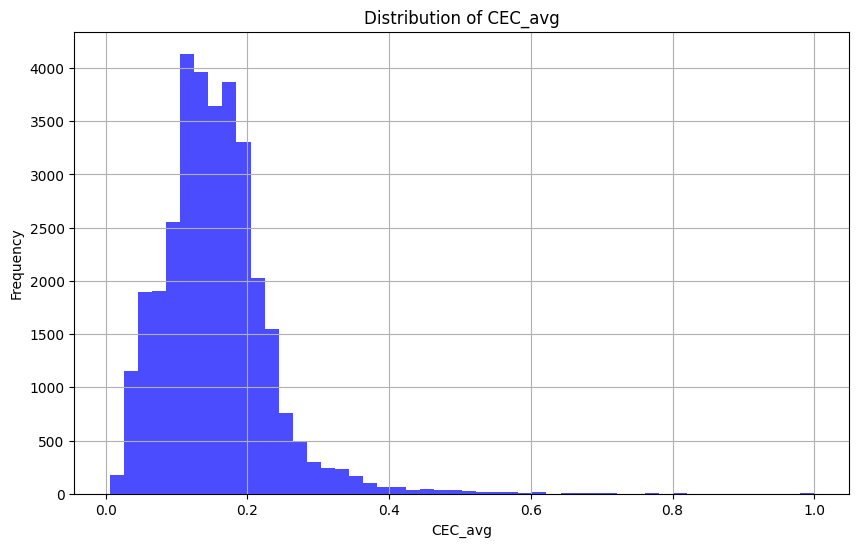

Mean of CEC_avg: 0.1545946275062203, Standard Deviation: 0.07531746923755579
Min of CEC_avg: 0.005405405405405406, Max of CEC_avg: 1.0


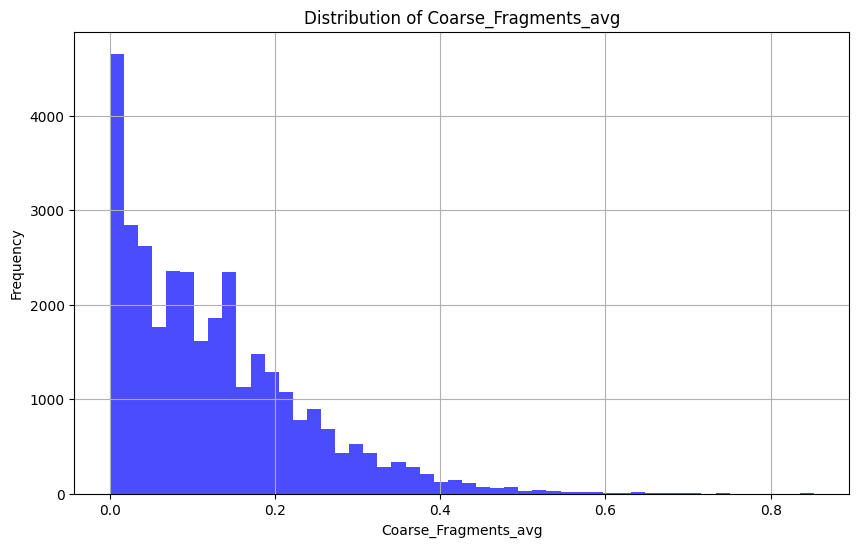

Mean of Coarse_Fragments_avg: 0.12655645911088576, Standard Deviation: 0.10877129109520853
Min of Coarse_Fragments_avg: 0.0, Max of Coarse_Fragments_avg: 0.8525345622119815


In [13]:
# For each env4nn, plot the distribution of env_info within profile_collection
for ivar in var4nn:
	if ivar in env_info.columns:
		plt.figure(figsize=(10, 6))
		plt.hist(env_info[ivar][profile_collection.flatten()], bins=50, color='blue', alpha=0.7)
		plt.title(f"Distribution of {ivar}")
		plt.xlabel(ivar)
		plt.ylabel("Frequency")
		plt.grid()
		plt.show()
		# Calculate the mean and standard deviation of the variable
		mean_value = np.nanmean(env_info[ivar][profile_collection.flatten()])
		std_value = np.nanstd(env_info[ivar][profile_collection.flatten()])
		print(f"Mean of {ivar}: {mean_value}, Standard Deviation: {std_value}")
		print(f"Min of {ivar}: {np.nanmin(env_info[ivar][profile_collection.flatten()])}, Max of {ivar}: {np.nanmax(env_info[ivar][profile_collection.flatten()])}")
	else:
		print(f"Variable {ivar} not found in env_info.")

In [5]:
#---------------------------------------------------
# training data
#---------------------------------------------------
# Input features (environmental covariates)
current_data_x = np.ones((len(profile_collection), max(len(var4nn), 20), 12, 13))*np.nan

# Fill in input features
# NOTE: env_info is indexed starting from 0, and profile_collection
# is also using zero-based indices
current_data_x[:, 0:len(var4nn), 0, 0] = np.array(env_info.loc[profile_collection[:, 0], var4nn])

# Monthly forcing variables
current_data_x[:, 0:12, 0, 1] = model_force_input_vector_cwd
current_data_x[:, 0:12, 0, 2] = model_force_input_vector_litter1
current_data_x[:, 0:12, 0, 3] = model_force_input_vector_litter2
current_data_x[:, 0:12, 0, 4] = model_force_input_vector_litter3
current_data_x[:, 0:12, 0, 5] = model_force_altmax_lastyear_profile
current_data_x[:, 0:12, 0, 6] = model_force_altmax_current_profile
current_data_x[:, 0:12, 0, 7] = model_force_nbedrock

# Forcing variables that apply for each depth layer
current_data_x[:, 0:20, 0:12, 8] = model_force_xio
current_data_x[:, 0:20, 0:12, 9] = model_force_xin
current_data_x[:, 0:20, 0:12, 10] = model_force_sand_vector
current_data_x[:, 0:20, 0:12, 11] = model_force_soil_temp_profile
current_data_x[:, 0:20, 0:12, 12] = model_force_soil_water_profile

# SOC labels: each row represents a location, each column represents an observation
# at a certain depth. Since locations have different numbers of observations, many entries are NaN.
current_data_y = np.ones((len(profile_collection), 3, 200))*np.nan
current_data_y[:, 0, :] = obs_soc_matrix
current_data_y[:, 1, :] = obs_POM_matrix
current_data_y[:, 2, :] = obs_MAOM_matrix

# Depth of each observation in current_data_y (same shape)
current_data_z = obs_depth_matrix

# Geographic coordinates
lons = np.array(env_info.loc[profile_collection[:, 0], "original_lon"])
lats = np.array(env_info.loc[profile_collection[:, 0], "original_lat"])
current_data_c = np.stack([lons, lats], axis=1)  # [profile, 2]: lon/lat of each site

# Remove sites with missing features or forcing variables
nan_loc = np.sum(current_data_x[:, 0:len(var4nn), 0, 0], axis = 1) + \
			np.sum(model_force_input_vector_cwd, axis = 1) + \
			np.sum(model_force_input_vector_litter1, axis = 1) + \
			np.sum(model_force_input_vector_litter2, axis = 1) + \
			np.sum(model_force_input_vector_litter3, axis = 1) + \
			np.sum(model_force_altmax_lastyear_profile, axis = 1) + \
			np.sum(model_force_altmax_current_profile, axis = 1) + \
			np.sum(model_force_nbedrock, axis = 1) + \
			np.sum(model_force_xio, axis = (1, 2)) + \
			np.sum(model_force_xin, axis = (1, 2)) + \
			np.sum(model_force_sand_vector, axis = (1, 2)) + \
			np.sum(model_force_soil_temp_profile, axis = (1, 2)) + \
			np.sum(model_force_soil_water_profile, axis = (1, 2))
# valid_profile_loc = np.where(np.isnan(nan_loc) == False)[0] 
nan_mask = ~np.isnan(nan_loc)

# Drop profiles with negative values in current_data_y
neg_mask = ~np.any(current_data_y < 0, axis=(1, 2))
# Combine the two masks
valid_profile_loc = np.where(nan_mask & neg_mask)[0]

current_data_y = current_data_y[valid_profile_loc, :, :]
current_data_z = current_data_z[valid_profile_loc, :]
current_data_x = current_data_x[valid_profile_loc, :, :, :]
current_data_c = current_data_c[valid_profile_loc, :]
current_data_profile_id = profile_collection[valid_profile_loc, 0]
obs_upper_depth_matrix = obs_upper_depth_matrix[valid_profile_loc, :]
obs_lower_depth_matrix = obs_lower_depth_matrix[valid_profile_loc, :]


print("Shape of current data x", current_data_x.shape)
print("Shape of current data y", current_data_y.shape)
print("Shape of current data z", current_data_z.shape)
print("Shape of current data c", current_data_c.shape)
print("Shape of current_data_profile_id", current_data_profile_id.shape)
print("Shape of obs upper depth matrix", obs_upper_depth_matrix.shape)
print("Shape of obs lower depth matrix", obs_lower_depth_matrix.shape)
print("Shape of env info", env_info.shape)

Shape of current data x (32623, 20, 12, 13)
Shape of current data y (32623, 3, 200)
Shape of current data z (32623, 200)
Shape of current data c (32623, 2)
Shape of current_data_profile_id (32623,)
Shape of obs upper depth matrix (32623, 200)
Shape of obs lower depth matrix (32623, 200)
Shape of env info (117212, 118)


Shape of env_info['BIO1']: (33286,)
Shape of obs_soc_matrix: (33286, 200)


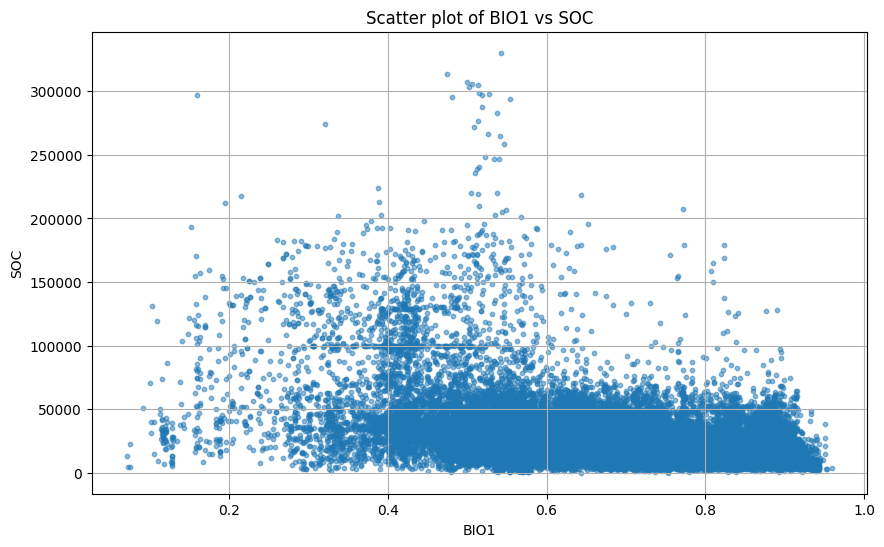

In [18]:
# Plot the scatter plot between env_info BIO1 and obs_soc_matrix
# first check the shape of env_info["BIO1"] and obs_soc_matrix
print("Shape of env_info['BIO1']:", env_info["BIO1"][profile_collection.flatten()].shape)
print("Shape of obs_soc_matrix:", obs_soc_matrix.shape)
plt.figure(figsize=(10, 6))
plt.scatter(env_info["BIO1"][profile_collection.flatten()], obs_soc_matrix[:,0], alpha=0.5, s=10)
plt.title("Scatter plot of BIO1 vs SOC")
plt.xlabel("BIO1")
plt.ylabel("SOC")
plt.grid()
plt.show()
                    

In [6]:
# Recreate the model
var_idx_to_emb = OrderedDict() 
model_class, model_kwargs = misc_utils.get_model(dummy_args, var4nn, var_idx_to_emb, device,
														para_index, torch.tensor(current_data_x), torch.tensor(current_data_y))
model = model_class(**model_kwargs).to(device)
print(model)
new_checkpoint_DDP = torch.load('D:/BINN/OUTPUT_DATA/neural_network/20250601-165700_KAN_ONELAYER_GRIDMARGIN_COMPAS2_9700234_lr=1e-02_fold=0_seed=111/opt_nn_20250601-165700_KAN_ONELAYER_GRIDMARGIN_COMPAS2_9700234_lr=1e-02_fold=0_seed=111.pt', map_location=device, weights_only=False)
# Create new OrderedDict that does not contain module
new_checkpoint = OrderedDict()
for key, value in new_checkpoint_DDP['model_state_dict'].items():
	new_key = key[7:]
	new_checkpoint[new_key] = value

model.load_state_dict(new_checkpoint)

# Get the average of the environmental features and save as new input
baseline_data_x = current_data_x.copy()
baseline_data_x[:, 0:len(var4nn), 0, 0] = np.mean(current_data_x[:, 0:len(var4nn), 0, 0], axis=0, keepdims=True)
baseline_env_info = baseline_data_x[:, 0:len(var4nn), 0, 0].copy()

checkpoint directory created: ./model
saving model version 0.0
mlp_wrapper(
  (var_idx_to_emb): ModuleDict()
  (mlp): MultKAN(
    (act_fun): ModuleList(
      (0): KANLayer(
        (base_fun): Identity()
      )
    )
    (base_fun): Identity()
    (symbolic_fun): ModuleList(
      (0): Symbolic_KANLayer()
    )
  )
  (sigmoid): Hardsigmoid()
)


In [ ]:
propotional_change = [0.02, 0.04, 0.06, 0.08, 0.1, -0.02, -0.04, -0.06, -0.08, -0.1]  # Proportional change in the environmental features

# Use data loader to save memory
batch_size = 128

# Helper function to combine the training data into a single tensor
class MergeDataset(Dataset):
	def __init__(self, data_x, data_y, data_z, data_c, profile_id, proda_para):
		self.data_x = data_x
		self.data_y = data_y
		self.data_z = data_z
		self.data_c = data_c
		self.profile_id = profile_id
		self.proda_para = proda_para

	def __len__(self):
		return len(self.data_x)

	def __getitem__(self, idx):
		return self.data_x[idx], self.data_y[idx], self.data_z[idx], self.data_c[idx], self.profile_id[idx], self.proda_para[idx]

 # Convert input into tensor first
current_data_x_tensor = torch.tensor(current_data_x, dtype=torch.float32, device=device)
current_data_y_tensor = torch.tensor(current_data_y, dtype=torch.float32, device=device)
current_data_z_tensor = torch.tensor(current_data_z, dtype=torch.float32, device=device)
current_data_c_tensor = torch.tensor(current_data_c, dtype=torch.float32, device=device)
current_data_profile_id_tensor = torch.tensor(current_data_profile_id, dtype=torch.int64, device=device)

input_dataset = MergeDataset(
	current_data_x_tensor, current_data_y_tensor, current_data_z_tensor, current_data_c_tensor, current_data_profile_id_tensor, torch.tensor(np.ones((len(current_data_profile_id), len(para_names))), dtype=torch.float32, device=device))
input_loader = DataLoader(input_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Initializa the variables to store the results
baseline_soc = torch.zeros((combined_profile_num, 20), dtype=torch.float32, device=device)
baseline_POM = torch.zeros((combined_profile_num, 20), dtype=torch.float32, device=device)
baseline_MAOM = torch.zeros((combined_profile_num, 20), dtype=torch.float32, device=device)
baseline_DOC = torch.zeros((combined_profile_num, 20), dtype=torch.float32, device=device)
baseline_MIC = torch.zeros((combined_profile_num, 20), dtype=torch.float32, device=device)

baseline_para = torch.zeros((combined_profile_num, len(para_names)), dtype=torch.float32, device=device)

# Bulk simulation
baseline_carbon_input = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_cpool_steady_state = (torch.ones((combined_profile_num, 140))*np.nan).to(device)
baseline_cpools_layer = (torch.ones((combined_profile_num, 20))*np.nan).to(device)
baseline_soc_layer = (torch.ones((combined_profile_num, 20))*np.nan).to(device)
baseline_total_res_time = (torch.ones((combined_profile_num, 20))*np.nan).to(device)
baseline_total_res_time_base = (torch.ones((combined_profile_num, 20))*np.nan).to(device)
baseline_res_time_base_pools = (torch.ones((combined_profile_num, 140))*np.nan).to(device)
baseline_t_scaler = (torch.ones((combined_profile_num, 20))*np.nan).to(device)
baseline_bulk_A_doc = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_bulk_E_mic = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_bulk_A_mic = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_bulk_A_POM = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_bulk_A_MAOM = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_w_scaler = (torch.ones((combined_profile_num, 20))*np.nan).to(device)
baseline_bulk_K = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_bulk_V = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_bulk_xi = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_bulk_I = (torch.ones((combined_profile_num, 1))*np.nan).to(device)
baseline_litter_fraction = (torch.ones((combined_profile_num, 1))*np.nan).to(device)	

# Get the baseline soc, POM, and MAOM values
for batch_data in input_loader:
	batch_data_x, batch_data_y, batch_data_z, batch_data_c, batch_profile_id, proda_para = batch_data
	# Move data to device
	batch_data_x = batch_data_x.to(device)
	batch_data_y = batch_data_y.to(device)
	batch_data_z = batch_data_z.to(device)
	batch_data_c = batch_data_c.to(device)
	batch_profile_id = batch_profile_id.to(device)
	proda_para = proda_para.to(device)

	# Get the baseline values
	model.eval()
	with torch.no_grad():
		baseline_soc_batch, baseline_params = model(batch_data_x, batch_data_z, batch_data_c, whether_predict = 1, PRODA_para = proda_para)

	baseline_soc[batch_profile_id, :] = baseline_soc_batch[:, 0, 0:20]
	baseline_POM[batch_profile_id, :] = baseline_soc_batch[:, 1, 0:20]
	baseline_MAOM[batch_profile_id, :] = baseline_soc_batch[:, 2, 0:20]
	baseline_DOC[batch_profile_id, :] = baseline_soc_batch[:, 3, 0:20]
	baseline_MIC[batch_profile_id, :] = baseline_soc_batch[:, 4, 0:20]
	baseline_para[batch_profile_id, :] = baseline_params

	# Bulk simulation
	baseline_carbon_input_temp, baseline_cpool_steady_state_temp, baseline_cpools_layer_temp, \
		baseline_soc_layer_temp, baseline_total_res_time_temp, baseline_total_res_time_base_temp, \
		baseline_res_time_base_pools_temp, baseline_t_scaler_temp, baseline_bulk_A_doc_temp, \
		baseline_bulk_E_mic_temp, baseline_bulk_A_mic_temp, baseline_bulk_A_POM_temp, \
		baseline_bulk_A_MAOM_temp, baseline_w_scaler_temp, baseline_bulk_K_temp, \
		baseline_bulk_V_temp, baseline_bulk_xi_temp, baseline_bulk_I_temp, \
		baseline_litter_fraction_temp = fun_bulk_simu(baseline_params, batch_data_x)
	
	# Store the results
	baseline_carbon_input[batch_profile_id, :] = baseline_carbon_input_temp
	baseline_cpool_steady_state[batch_profile_id, :] = baseline_cpool_steady_state_temp
	baseline_cpools_layer[batch_profile_id, :] = baseline_cpools_layer_temp
	baseline_soc_layer[batch_profile_id, :] = baseline_soc_layer_temp
	baseline_total_res_time[batch_profile_id, :] = baseline_total_res_time_temp
	baseline_total_res_time_base[batch_profile_id, :] = baseline_total_res_time_base_temp
	baseline_res_time_base_pools[batch_profile_id, :] = baseline_res_time_base_pools_temp
	baseline_t_scaler[batch_profile_id, :] = baseline_t_scaler_temp
	baseline_bulk_A_doc[batch_profile_id, :] = baseline_bulk_A_doc_temp
	baseline_bulk_E_mic[batch_profile_id, :] = baseline_bulk_E_mic_temp
	baseline_bulk_A_mic[batch_profile_id, :] = baseline_bulk_A_mic_temp
	baseline_bulk_A_POM[batch_profile_id, :] = baseline_bulk_A_POM_temp
	baseline_bulk_A_MAOM[batch_profile_id, :] = baseline_bulk_A_MAOM_temp
	baseline_w_scaler[batch_profile_id, :] = baseline_w_scaler_temp
	baseline_bulk_K[batch_profile_id, :] = baseline_bulk_K_temp
	baseline_bulk_V[batch_profile_id, :] = baseline_bulk_V_temp
	baseline_bulk_xi[batch_profile_id, :] = baseline_bulk_xi_temp
	baseline_bulk_I[batch_profile_id, :] = baseline_bulk_I_temp
	baseline_litter_fraction[batch_profile_id, :] = baseline_litter_fraction_temp
# End of the loop



# Get the avg baseline values
avg_baseline_soc = np.nanmean(np.nansum(baseline_soc, axis=0) * dz[0:20])
avg_baseline_POM = np.nanmean(np.nansum(baseline_POM, axis=0) * dz[0:20])
avg_baseline_MAOM = np.nanmean(np.nansum(baseline_MAOM, axis=0) * dz[0:20])
avg_baseline_DOC = np.nanmean(np.nansum(baseline_DOC, axis=0) * dz[0:20])
avg_baseline_MIC = np.nanmean(np.nansum(baseline_MIC, axis=0) * dz[0:20])
avg_baseline_para = np.nanmean(baseline_para, axis=0)

# Print the baseline values
print("Baseline SOC: ", avg_baseline_soc)
print("Baseline POM: ", avg_baseline_POM)
print("Baseline MAOM: ", avg_baseline_MAOM)
print("Baseline DOC: ", avg_baseline_DOC)
print("Baseline MIC: ", avg_baseline_MIC)
print("Baseline parameters: ", avg_baseline_para)

# Save the baseline values into a txt file
# Create the output directory if it doesn't exist
if not os.path.exists(data_dir_output + 'baseline_values/'):
	os.makedirs(data_dir_output + 'baseline_values/')

baseline_values = {
	'SOC': avg_baseline_soc,
	'POM': avg_baseline_POM,
	'MAOM': avg_baseline_MAOM,
	'DOC': avg_baseline_DOC,
	'MIC': avg_baseline_MIC,
	'Parameters': avg_baseline_para.tolist()
}
# baseline average pool values
baseline_file = data_dir_output + 'baseline_values/baseline_values.txt'
with open(baseline_file, 'w') as f:
	for key, value in baseline_values.items():
		f.write(f"{key}: {value}\n")

# baseline carbon pool steady state
with open(data_dir_output + 'baseline_values/baseline_soc.txt', 'w') as f:
	for value in baseline_soc.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_POM.txt', 'w') as f:
	for value in baseline_POM.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_MAOM.txt', 'w') as f:
	for value in baseline_MAOM.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_DOC.txt', 'w') as f:
	for value in baseline_DOC.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_MIC.txt', 'w') as f:
	for value in baseline_MIC.cpu().numpy():
		f.write(f"{value}\n")

# baseline parameters
with open(data_dir_output + 'baseline_values/baseline_parameters.txt', 'w') as f:
	for value in baseline_para.cpu().numpy():
		f.write(f"{value}\n")

# baseline bulk simulation results
with open(data_dir_output + 'baseline_values/baseline_carbon_input.txt', 'w') as f:
	for value in baseline_carbon_input.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_cpool_steady_state.txt', 'w') as f:
	for value in baseline_cpool_steady_state.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_cpools_layer.txt', 'w') as f:
	for value in baseline_cpools_layer.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_soc_layer.txt', 'w') as f:
	for value in baseline_soc_layer.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_total_res_time.txt', 'w') as f:
	for value in baseline_total_res_time.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_total_res_time_base.txt', 'w') as f:
	for value in baseline_total_res_time_base.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_res_time_base_pools.txt', 'w') as f:
	for value in baseline_res_time_base_pools.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_t_scaler.txt', 'w') as f:
	for value in baseline_t_scaler.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_A_doc.txt', 'w') as f:
	for value in baseline_bulk_A_doc.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_E_mic.txt', 'w') as f:
	for value in baseline_bulk_E_mic.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_A_mic.txt', 'w') as f:
	for value in baseline_bulk_A_mic.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_A_POM.txt', 'w') as f:
	for value in baseline_bulk_A_POM.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_A_MAOM.txt', 'w') as f:
	for value in baseline_bulk_A_MAOM.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_w_scaler.txt', 'w') as f:
	for value in baseline_w_scaler.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_K.txt', 'w') as f:
	for value in baseline_bulk_K.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_V.txt', 'w') as f:
	for value in baseline_bulk_V.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_xi.txt', 'w') as f:
	for value in baseline_bulk_xi.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_bulk_I.txt', 'w') as f:
	for value in baseline_bulk_I.cpu().numpy():
		f.write(f"{value}\n")
with open(data_dir_output + 'baseline_values/baseline_litter_fraction.txt', 'w') as f:
	for value in baseline_litter_fraction.cpu().numpy():
		f.write(f"{value}\n")



Baseline SOC:  32559717.379999995
Baseline POM:  2497485.9020625
Baseline MAOM:  29444650.496000003
Baseline DOC:  436499.61264062504
Baseline MIC:  181174.27010546875
Baseline parameters:  [0.1417976  0.11336083 0.09516014 0.11917043 0.13910094 0.14167295
 0.23640716 0.08788463 0.1058013  0.10509171 0.16967994 0.20980337
 0.2295779  0.22486632 0.23049928 0.03919697 0.12873402 0.03376308
 0.05397393 0.17175646 0.09605483]


In [ ]:
# Adjust each environmental feature by the proportional change and get the new predictions
output_categories = ['soc_change', 'POM_change', 'MAOM_change', 'DOC_change', 'MIC_change', 'para_change']
for env_info_id in range(len(var4nn)):
	# Create a folder to save the results
	env_output_dir = data_dir_output + f'{var4nn[env_info_id]}/'
	os.makedirs(env_output_dir, exist_ok=True)
	soc_change = np.zeros((len(propotional_change)), dtype=np.float32)
	POM_change = np.zeros((len(propotional_change)), dtype=np.float32)
	MAOM_change = np.zeros((len(propotional_change)), dtype=np.float32)
	DOC_change = np.zeros((len(propotional_change)), dtype=np.float32)
	MIC_change = np.zeros((len(propotional_change)), dtype=np.float32)
	para_change = np.zeros((len(propotional_change), len(para_names)), dtype=np.float32)


	for i, change in enumerate(propotional_change):
    	# Initialize variables to store the changes
		soc_change_temp = np.zeros((combined_profile_num), dtype=np.float32)
		POM_change_temp = np.zeros((combined_profile_num), dtype=np.float32)
		MAOM_change_temp = np.zeros((combined_profile_num), dtype=np.float32)
		DOC_change_temp = np.zeros((combined_profile_num), dtype=np.float32)
		MIC_change_temp = np.zeros((combined_profile_num), dtype=np.float32)
		para_change_temp = np.zeros((combined_profile_num, len(para_names)), dtype=np.float32)

		# Loop through the input data in batches
		for batch_data in input_loader:
			batch_data_x, batch_data_y, batch_data_z, batch_data_c, batch_profile_id, proda_para = batch_data
			# Move data to device
			batch_data_x = batch_data_x.to(device)
			batch_data_y = batch_data_y.to(device)
			batch_data_z = batch_data_z.to(device)
			batch_data_c = batch_data_c.to(device)
			batch_profile_id = batch_profile_id.to(device)
			proda_para = proda_para.to(device)

			# Adjust the environmental feature
			batch_data_x[:, env_info_id, 0, 0] += batch_data_x[:, env_info_id, 0, 0] * (1 + change)
			# Drop rows with values outside [0, 1]
			invalid_loc = np.where((batch_data_x[:, env_info_id, 0, 0] < 0) | (batch_data_x[:, env_info_id, 0, 0] > 1))[0]
			if len(invalid_loc) > 0:
				batch_data_x = batch_data_x[~invalid_loc, :, :, :]
				batch_data_y = batch_data_y[~invalid_loc, :, :]
				batch_data_z = batch_data_z[~invalid_loc, :]
				batch_data_c = batch_data_c[~invalid_loc, :]
				proda_para = proda_para[~invalid_loc, :]
				batch_profile_id = batch_profile_id[~invalid_loc]

			# Get the new predictions
			model.eval()
			with torch.no_grad():
				soc_batch, para_batch = model(batch_data_x, batch_data_z, batch_data_c, whether_predict=1, PRODA_para=proda_para)

			soc_change_temp[batch_profile_id] = np.nanmean(np.nansum(soc_batch[:, 0, 0:20].cpu().numpy() * dz[0:20], axis=0))
			POM_change_temp[batch_profile_id] = np.nanmean(np.nansum(soc_batch[:, 1, 0:20].cpu().numpy() * dz[0:20], axis=0))
			MAOM_change_temp[batch_profile_id] = np.nanmean(np.nansum(soc_batch[:, 2, 0:20].cpu().numpy() * dz[0:20], axis=0))
			DOC_change_temp[batch_profile_id] = np.nanmean(np.nansum(soc_batch[:, 3, 0:20].cpu().numpy() * dz[0:20], axis=0))
			MIC_change_temp[batch_profile_id] = np.nanmean(np.nansum(soc_batch[:, 4, 0:20].cpu().numpy() * dz[0:20], axis=0))
			para_change_temp[batch_profile_id, :] = np.nanmean(para_batch.cpu().numpy(), axis=0)

		# Sum the changes across all batches
		soc_change[i] = np.mean(soc_change_temp)
		POM_change[i] = np.mean(POM_change_temp)
		MAOM_change[i] = np.mean(MAOM_change_temp)
		DOC_change[i] = np.mean(DOC_change_temp)
		MIC_change[i] = np.mean(MIC_change_temp)
		para_change[i, :] = np.mean(para_change_temp, axis=0)

	# Save the changes to a file
	for j, output_category in enumerate(output_categories):
		output_file = env_output_dir + f'{output_category}.txt'
		if output_category == 'soc_change':
			np.savetxt(output_file, soc_change, fmt='%.6f')
		elif output_category == 'POM_change':
			np.savetxt(output_file, POM_change, fmt='%.6f')
		elif output_category == 'MAOM_change':
			np.savetxt(output_file, MAOM_change, fmt='%.6f')
		elif output_category == 'DOC_change':
			np.savetxt(output_file, DOC_change, fmt='%.6f')
		elif output_category == 'MIC_change':
			np.savetxt(output_file, MIC_change, fmt='%.6f')
		elif output_category == 'para_change':
			np.savetxt(output_file, para_change, fmt='%.6f')
	
	print(f"Changes for {var4nn[env_info_id]} saved to {env_output_dir}")

    		

			
	

In [ ]:
# Plot the KAN model
PLOT_DIR = os.path.join('D:/BINN/OUTPUT_DATA/neural_network', job_id, 'visualizations')
# Produce edge/node importance scores
model.mlp.attribute()
model.mlp.node_attribute()

# Plot the unpruned model
model.mlp.plot(folder=os.path.join(PLOT_DIR, "splines"), in_vars=var4nn, out_vars=para_names, scale=5, varscale=0.1)
plt.savefig(os.path.join(PLOT_DIR, f"Best_model_kan_plot.png"))
plt.close()

# Plot the pruned model
pruned_model = model.mlp.prune(node_th=0.03, edge_th=0.03)
pruned_model.plot(folder=os.path.join(PLOT_DIR, "splines"), in_vars=var4nn, out_vars=para_names, scale=5, varscale=0.1)
plt.savefig(os.path.join(PLOT_DIR, f"Best_model_kan_plot_pruned.png"))
plt.close()


Exception: model hasn't seen any data yet.